# Physics 234 Final
## April 21 9-12 AM

Do the following problems. Use the Jupyter notebook, inserting your code and any textual answers/explanations in cells between the questions. (Feel free to add additional cells!) Marks will be given based on how clearly you demonstrate your understanding.

There are no restrictions on downloading from the internet, eclass, or the use of books, notes, or any other widely available computing resources. However, you are not allowed to communicate with each other or collaborate in any way and uploading to the internet or sending or receiving direct communications is not appropriate. AI engines like ChatGPT are not appropriate.  

When you are finished, upload the jupyter notebook to eclass. Eclass times out at 12:00 so make sure that you upload things before then. Also be careful to save the notebook periodically and that you upload the file that contains all your work.

1. Consider the function $$f(x)=10e^{-(\cos(x)^2+3\sin(x)-1)}$$.

Write a function that evaluates this. Print a table of values of of the function at x=0,0.5,1,1.5,2,2.5,3,3.5,4, outputting 9 lines that read like 'f(0.0)=value'.  

Plot the function.

Find and plot the numerical derivative.

f(0.0)=    10.0
f(0.8)=   2.059
f(1.5)=   1.357
f(2.2)=   1.775
f(3.0)=    6.68
f(3.8)=   77.01
f(4.5)=   488.2
f(5.2)=   275.1
f(6.0)=    25.0


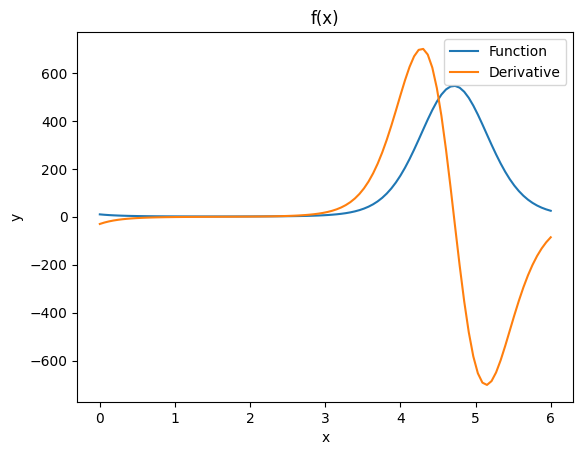

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def f(x):
        return 10*np.exp(-(np.cos(x)**2+3*np.sin(x)-1))
    
def fdir(x):
    xplus=(x+5e-6)
    xminus=(x-5e-6)
    return (f(xplus)-f(xminus))/(xplus-xminus)

xlist= np.linspace(0,6,9)
tov=np.array([xlist,f(xlist)])
for v in tov.transpose():
    print(f'f({v[0]:3.1f})= {v[1]:7.4}')

xlist2=np.linspace(0,6,100)
plt.title("f(x)")
plt.xlabel('x')
plt.ylabel('y')
plt.plot(xlist2,f(xlist2),label='Function')
plt.plot(xlist2,fdir(xlist2),label='Derivative')
#plt.yscale("log")
plt.legend()
plt.show()

# 2.  Energy spectrum of electron-positron pairs
The nucleus of $^{16}$O has its lowest excited state at 6.05 MeV.  It can only decay by emitting an electron-positron pair (since a decay emitting a photon is forbidden by angular momentum conservation).  A positron is the antiparticle of the electron- so it has identical mass, but positive charge.  The energy spectrum is proportional to the following expression:
$$\frac{dN}{dE_+}=2p_+p_-(E_+E_--m^2c^4)$$
where $N$ is the number of decays, $E_+$ is the energy of the positron, $E_-$ is the energy of the electron, $p_+$ is the energy of the positron, $p_-$ the momentum of the electron, $mc^2=0.511$ MeV is the rest mass- the energy equivalent of the mass of both an electron or a positron, and $c$ is the speed of light.

We have the following (relativistic) relationships (which are all you need to know!- the physics is all in these equations):
    $$E_+ + E_-=6.05,$$ the conservation of energy
    $$p^2c^2+m^2c^4=E^2,$$ the relativistic equation for momentum

 a. Write a function that calculates $\frac{dN}{dE_+}(E_+)$.  Plot the function for the entire energy range.  Note that the lowest energy for an positron is the rest mass, and the maximum energy is $6.05-mc^2$.
 
 *This function is used for several following questions.  If you are unable to write this function, continue the exam using the function from question(1) instead of $\frac{dN}{dE_+}(E_+)$. This will result in a penalty, but will allow you to do the other questions.*

Text(0, 0.5, 'dN/dE [1/MeV]')

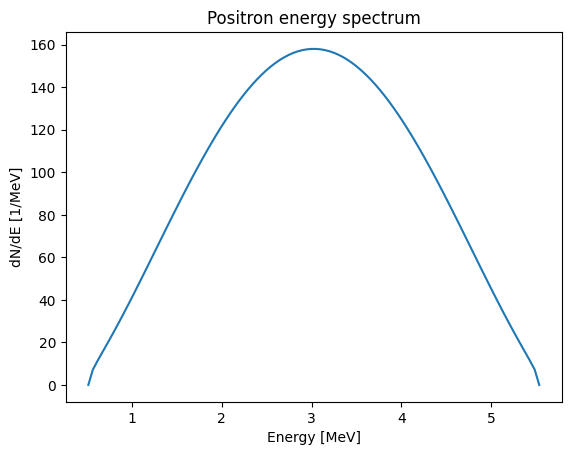

In [29]:
mc2=0.511
def dNdE(Ep):
    Em=6.05-Ep
#    print(Ep,Em)
    pcp=np.where(Ep>mc2,np.sqrt(Ep**2-mc2**2),0)
    pcm=np.where(Em>mc2,np.sqrt(Em**2-mc2**2),0)
    return 2*pcp*pcm*(Ep*Em-mc2**2)

elist=np.linspace(mc2,6.05-mc2,100)
plt.plot(elist,dNdE(elist))
plt.title('Positron energy spectrum')
plt.xlabel('Energy [MeV]')
plt.ylabel('dN/dE [1/MeV]')

b.  Using the "throw and pick" method of generating random numbers, generate 100,000 positron energies. Plot the histogram of energies, with 100 bins between 0 and 6 MeV.  

Text(0, 0.5, 'Number of positrons/energy bin')

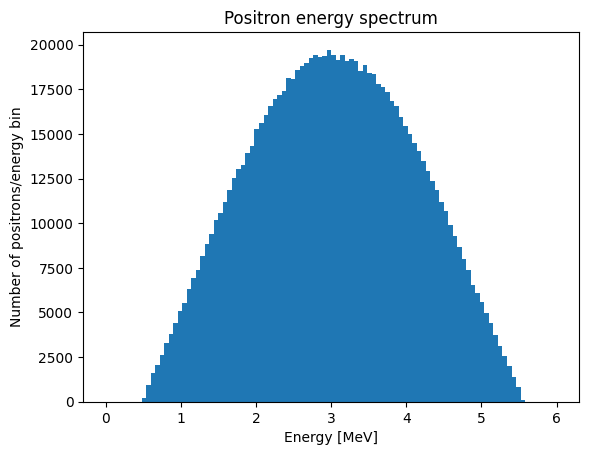

In [31]:
rng=np.random.default_rng()
E=rng.random(2000000)*(6.05-2*mc2)+mc2
x=dNdE(E)
y=160*rng.random(2000000)
xx=E[(x>y).nonzero()[0]]
plt.hist(xx[:1000000],100,range=[0,6.])
plt.title("Positron energy spectrum")
plt.xlabel('Energy [MeV]')
plt.ylabel('Number of positrons/energy bin')

c.  Normalize the function to make it into a probability distribution, $\frac{dP}{dE_+}(E_+)$, (with an integral =1).  To do this, do:
$$\frac{dP(E_+)}{dE_+}=\frac{\frac{dN}{dE_+}(E_+)}{\int_{E_{+,min}}^{E_{+,max}} dE_+ \frac{dN}{dE_+}(E_+)}$$

486.1354114010448


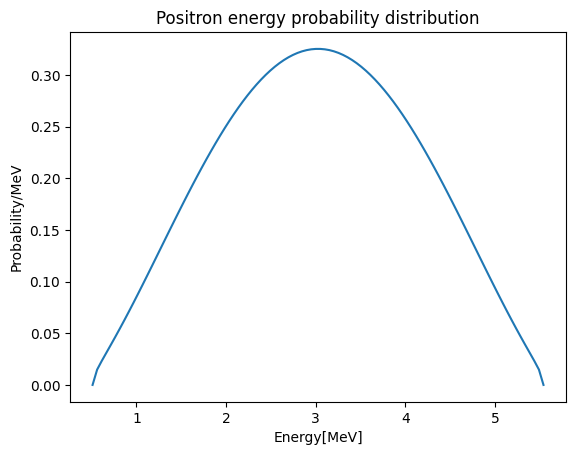

In [32]:
from scipy.integrate import quad
N=quad(dNdE,mc2,6.05-mc2)[0]
print(N)
def P(E):
    return np.where(mc2<=E,dNdE(E)/N,0)

plt.plot(elist,P(elist))
plt.title('Positron energy probability distribution')
plt.xlabel('Energy[MeV]')
plt.ylabel('Probability/MeV')
plt.show()

d.  Write and plot the "inverse function"-- ie, $f(x)$.  Given x, with $0\le x \le 1$, find

$$\int_{E_+,min}^{f(x)} P(E_+)dE_+=x$$

Text(0, 0.5, 'Energy [MeV]')

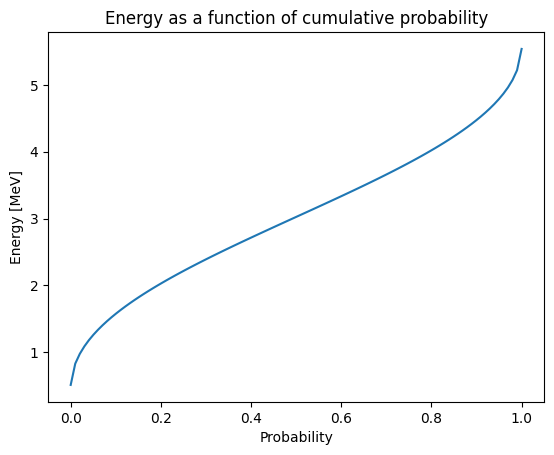

In [33]:
from scipy.optimize import root
def f(xx):
    return np.array([root(lambda y:quad(P,mc2,y)[0]-x, 3).x[0] for x in np.asarray(xx)])
plist=np.linspace(0,1,100)
#fplist=[f(p) for p in plist]
plt.plot(plist,f(plist))
plt.title('Energy as a function of cumulative probability')
plt.xlabel('Probability')
plt.ylabel('Energy [MeV]')

e.  Interpolate $f(x)$. Plot the interpolation, testing it against the actual function.

Text(0, 0.5, 'Energy[MeV]')

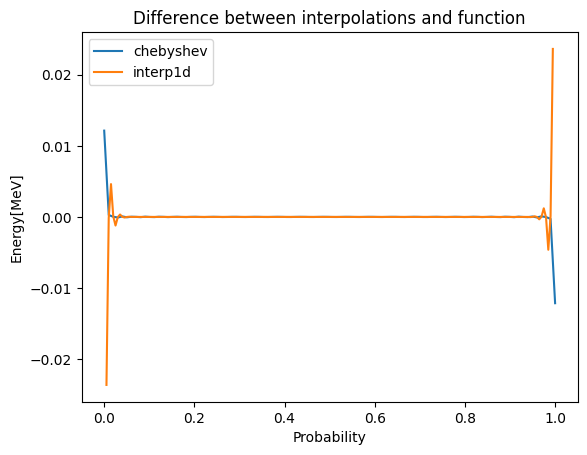

In [34]:
from numpy.polynomial.chebyshev import chebinterpolate,chebval
from scipy.interpolate import interp1d
def f2cheb(x): #argument from 0-1
    return 2*x-1
def fcheb(x): #argument from -1 to 1
    return f((1+x)/2)

cheb=chebinterpolate(fcheb,60)
def interp(x):
    return chebval(2*x-1,cheb)

interp2=interp1d(plist,f(plist),kind='cubic')

plist2=np.linspace(0,1,200)[1:-1]  #note this has finer steps than plist
plt.plot(plist,interp(plist)-f(plist),label='chebyshev')
plt.plot(plist2,interp2(plist2)-f(plist2),label='interp1d')
plt.title("Difference between interpolations and function")
plt.legend()
plt.xlabel('Probability')
plt.ylabel('Energy[MeV]')


Text(0, 0.5, 'Energy [MeV]')

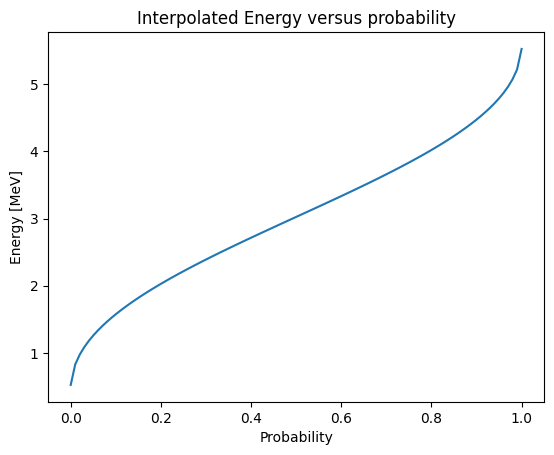

In [35]:
plt.plot(plist,interp(plist))
plt.title('Interpolated Energy versus probability')
plt.xlabel('Probability')
plt.ylabel('Energy [MeV]')


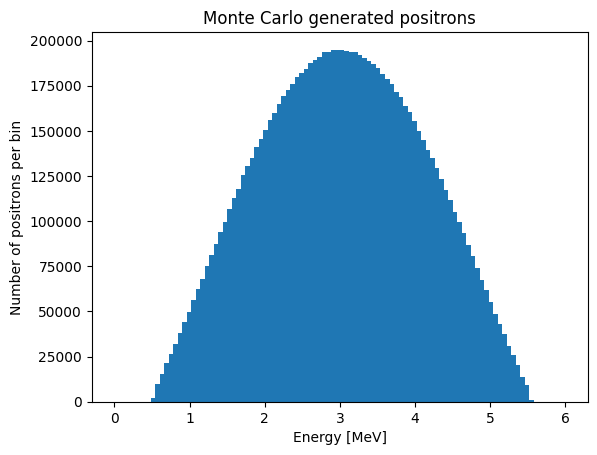

In [36]:
e=interp(rng.random(10000000))
plt.hist(e,100,range=[0,6])
plt.title("Monte Carlo generated positrons")
plt.xlabel("Energy [MeV]")
plt.ylabel("Number of positrons per bin")
plt.show()

# 3.  Trajectories

Run the following block of code to import a function $\vec{B}(\vec{r}).$  (You will also need to download the file br.pickle from eClass.) This function has calculated and interpolated the magnetic field $\vec{B}$ at a point $\vec{r}$ for an "intermediate image spectrometer", which consists of two large coils around a vacuum chamber.  The units of B are in Tesla, and positions in meters.

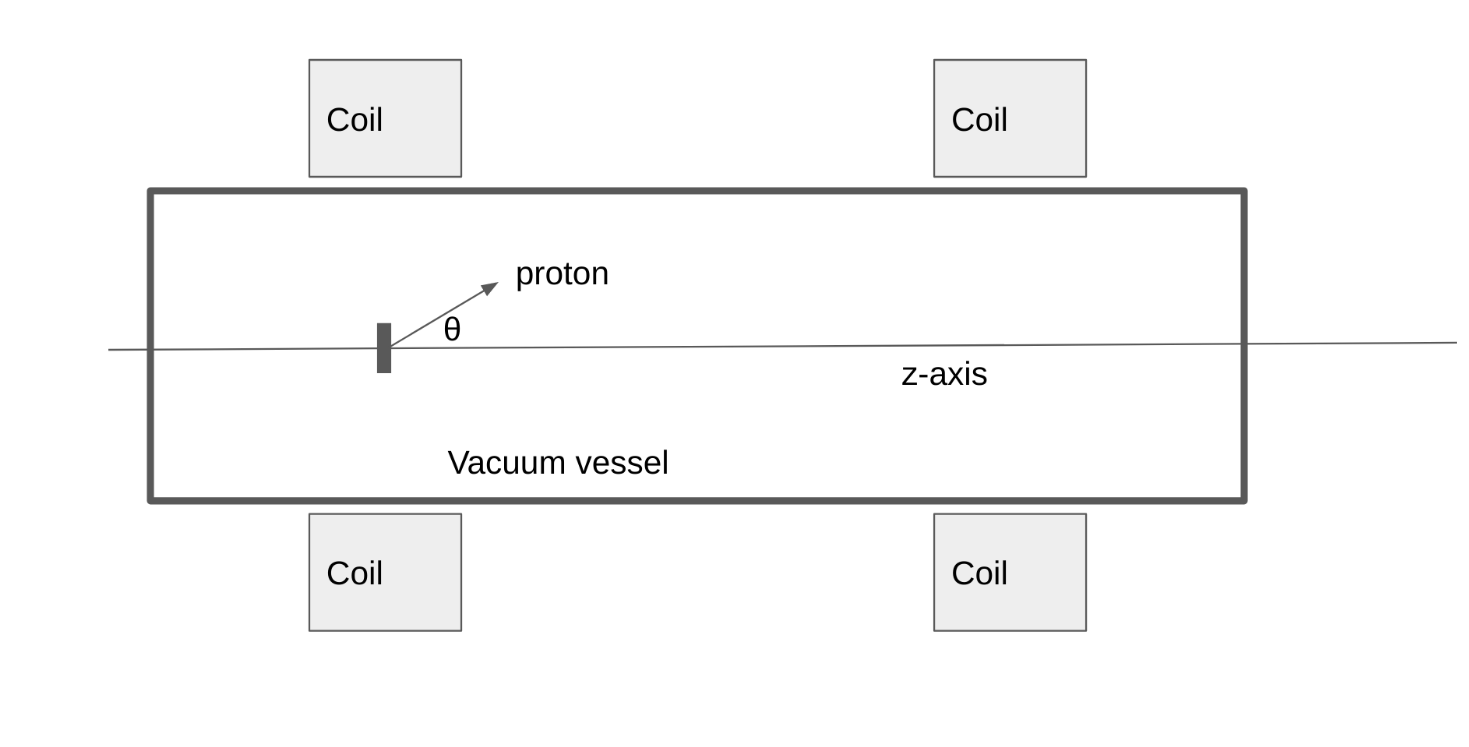

a.  Plot the z-component of the magnetic field along the x-axis.  Then make a single plot showing the x,y,and z components along the line (0.20,0,z) for -0.60<z<0.60 m. Repeat for the lines (0,0.20,z) and (-0.20,0,z),    



In [37]:
import numpy as np
import pickle
from numpy.polynomial.chebyshev import chebval2d
with open("br.pickle","rb")as f:
    (cX2,cZ2,mid,halfrange,halfrange2)=pickle.load(f,encoding='latin1')
    
halfrange2[1]=1.0 #stop divide by zero

def BrhoCheb2(r):
    if r[2]<0:
        r[2]=-r[2]
        factor=-1
    else:
        factor=1
    x=(r-mid)/halfrange2
    return factor*chebval2d(x[0],x[2],cX2)
def BzCheb2(r):
    r[2]=np.abs(r[2]) # apply symmetry
    x=(r-mid)/halfrange2
    return chebval2d(x[0],x[2],cZ2)

def B(r):
    rho=np.linalg.norm(r[:2])
    Brho=BrhoCheb2([rho,0,r[2]])
    Bz=BzCheb2([rho,0,r[2]])
    if rho>0:
        Bx=r[0]/rho*Brho
        By=r[1]/rho*Brho
    else:
        Bx=0
        By=0
    return np.array([Bx,By,Bz]) 



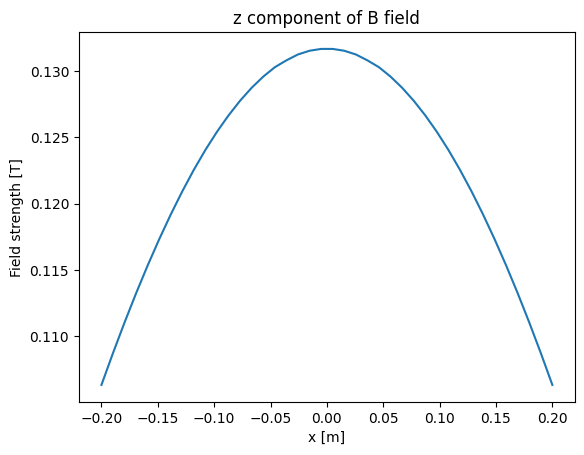

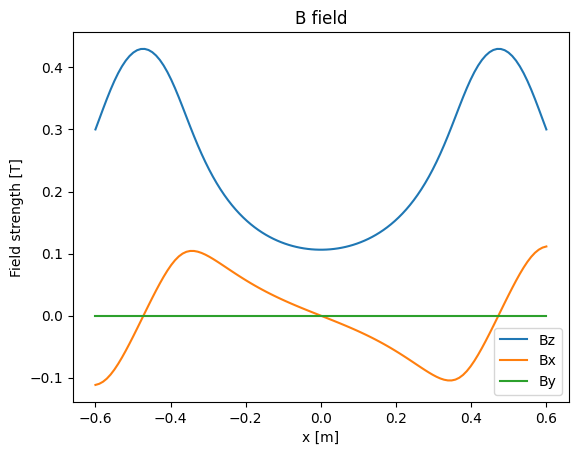

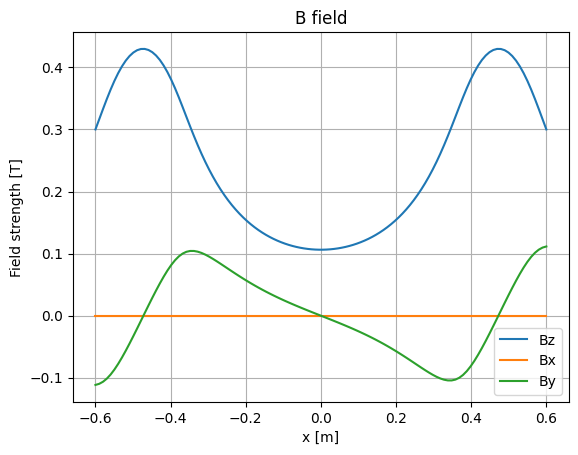

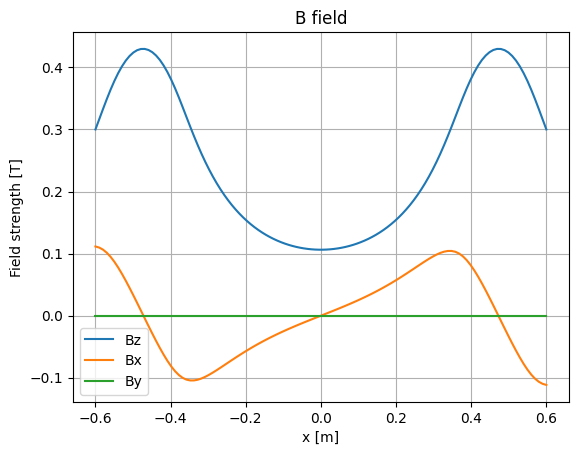

In [38]:
xlist=np.linspace(-0.20,0.20,40)
zlist=np.linspace(-0.60,0.60,120)
Bzl=np.array([B(np.array([x,0,0]))[2] for x in xlist])


plt.plot(xlist,Bzl)
plt.title("z component of B field")
plt.xlabel("x [m]")
plt.ylabel('Field strength [T]')
plt.show()
rho0=0.20

Bz2=np.array([B(np.array([rho0,0,z]))[2] for z in zlist])
Bx2=np.array([B(np.array([rho0,0,z]))[0] for z in zlist])
By2=np.array([B(np.array([rho0,0,z]))[1] for z in zlist])
plt.plot(zlist,Bz2,label='Bz')
plt.plot(zlist,Bx2,label='Bx')
plt.plot(zlist,By2,label='By')
plt.legend()
plt.title("B field")
plt.xlabel("x [m]")
plt.ylabel('Field strength [T]')
plt.show()
Bz2=np.array([B(np.array([0,rho0,z]))[2] for z in zlist])
Bx2=np.array([B(np.array([0,rho0,z]))[0] for z in zlist])
By2=np.array([B(np.array([0,rho0,z]))[1] for z in zlist])
plt.plot(zlist,Bz2,label='Bz')
plt.plot(zlist,Bx2,label='Bx')
plt.plot(zlist,By2,label='By')
plt.legend()
plt.title("B field")
plt.xlabel("x [m]")
plt.ylabel('Field strength [T]')
plt.grid()
plt.show()

Bz2=np.array([B(np.array([-rho0,0,z]))[2] for z in zlist])
Bx2=np.array([B(np.array([-rho0,0,z]))[0] for z in zlist])
By2=np.array([B(np.array([-rho0,0,z]))[1] for z in zlist])
plt.plot(zlist,Bz2,label='Bz')
plt.plot(zlist,Bx2,label='Bx')
plt.plot(zlist,By2,label='By')
plt.legend()
plt.title("B field")
plt.xlabel("x [m]")
plt.ylabel('Field strength [T]')
plt.grid()
plt.show()

b.  Protons with a non-relativistic energy of 44 keV are emitted from a point at (0,0,-0.502) m.  The force, $\vec{F}$ on a particle with charge $q$ moving in a magnetic field is given by:
$$\vec{F}=q\vec{v}\times\vec{B}$$
where $\vec{v}$ is the velocity of the particle and $\vec{B}$ is the magnetic field.  

Solve for the trajectories of protons emitted at angles $\theta=\pi/10,\pi/12,\pi/16,\pi/20,\pi/50$ with respect to the z-axis. Stop the integrations when protons either leave the spectrometer at z=0.60 meters, or return to within 1 cm of the axis.  

Plot $\rho=\sqrt{x^2+y^2}$ versus $z$ for the trajectories.


In [39]:
from scipy.constants import m_p,e,c
def dxvdt(t,xarg):
    x=xarg[:3]
    v=xarg[3:]
#    print(xarg,B(x))
    a=e*np.cross(v,B(x))/m_p
    ret=np.array([v,a]).reshape(-1)
#    print(ret)
    return ret

from scipy.integrate import solve_ivp
energy = 4.4e4*e
v0=np.sqrt(2*energy/m_p)

def term(t,xarg):
    rho=np.linalg.norm(xarg[:2])
    z=xarg[2]
    return (rho-0.01)*(z-0.60)
term.terminal=True
term.direction=1
    

theta=np.pi/8
tlist=np.linspace(0,4e-7,100)
def pltsol(theta):
    sol=solve_ivp(dxvdt,(0,4e-7),[0,0,-.502,v0*np.sin(theta),0,v0*np.cos(theta)],t_eval=tlist,events=term)
    plt.plot(sol.y[2,:],np.linalg.norm(sol.y[:2,:],axis=0),label=f'theta={theta:5.2}$')
    
#    plt.plot(sol.y[1,:],sol.y[2,:])

#    print(f'Theta={theta}')
    return

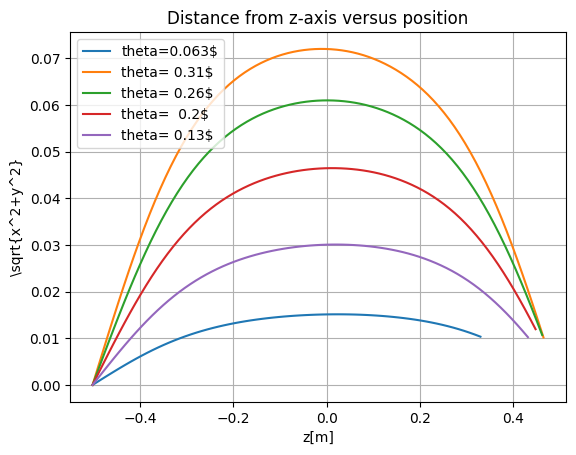

In [40]:
pltsol(np.pi/50)
pltsol(np.pi/10)
pltsol(np.pi/12)
pltsol(np.pi/16)
pltsol(np.pi/25)
plt.legend()
plt.title("Distance from z-axis versus position")
plt.xlabel('z[m]')
plt.ylabel('\sqrt{x^2+y^2}')
plt.grid()
